# Task 1: Data Loading, EDA & Preprocessing

### Objective
Load and understand the Breast Cancer Wisconsin dataset and prepare it for neural network training.

### Expected Output
Dataset shape, target class counts, and descriptive statistics of the features.

In [285]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

sns.set_style('whitegrid')

data = load_breast_cancer(as_frame=True)

X = data.data
y = data.target

print("X Shape:", X.shape)
print("\nTarget Class Counts:")
print(y.value_counts())

print("\nFeature Statistics:")
display(X.describe())

X Shape: (569, 30)

Target Class Counts:
target
1    357
0    212
Name: count, dtype: int64

Feature Statistics:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


## 1.2 Class Distribution

The dataset contains two classes:

- 0 = Malignant
- 1 = Benign

The class distribution is slightly imbalanced because there are more benign cases than malignant cases.

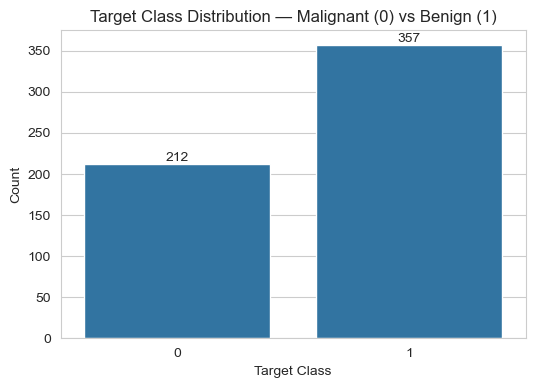

In [286]:
plt.figure(figsize=(6, 4))

ax = sns.countplot(x=y)

plt.title('Target Class Distribution — Malignant (0) vs Benign (1)')
plt.xlabel('Target Class')
plt.ylabel('Count')

for container in ax.containers:
    ax.bar_label(container)

plt.show()

## 1.3 Feature Correlation Heatmap

The correlation heatmap helps us understand how strongly different features are related to each other.

Some features such as radius, perimeter and area are highly correlated because they describe related properties of the cell nucleus.

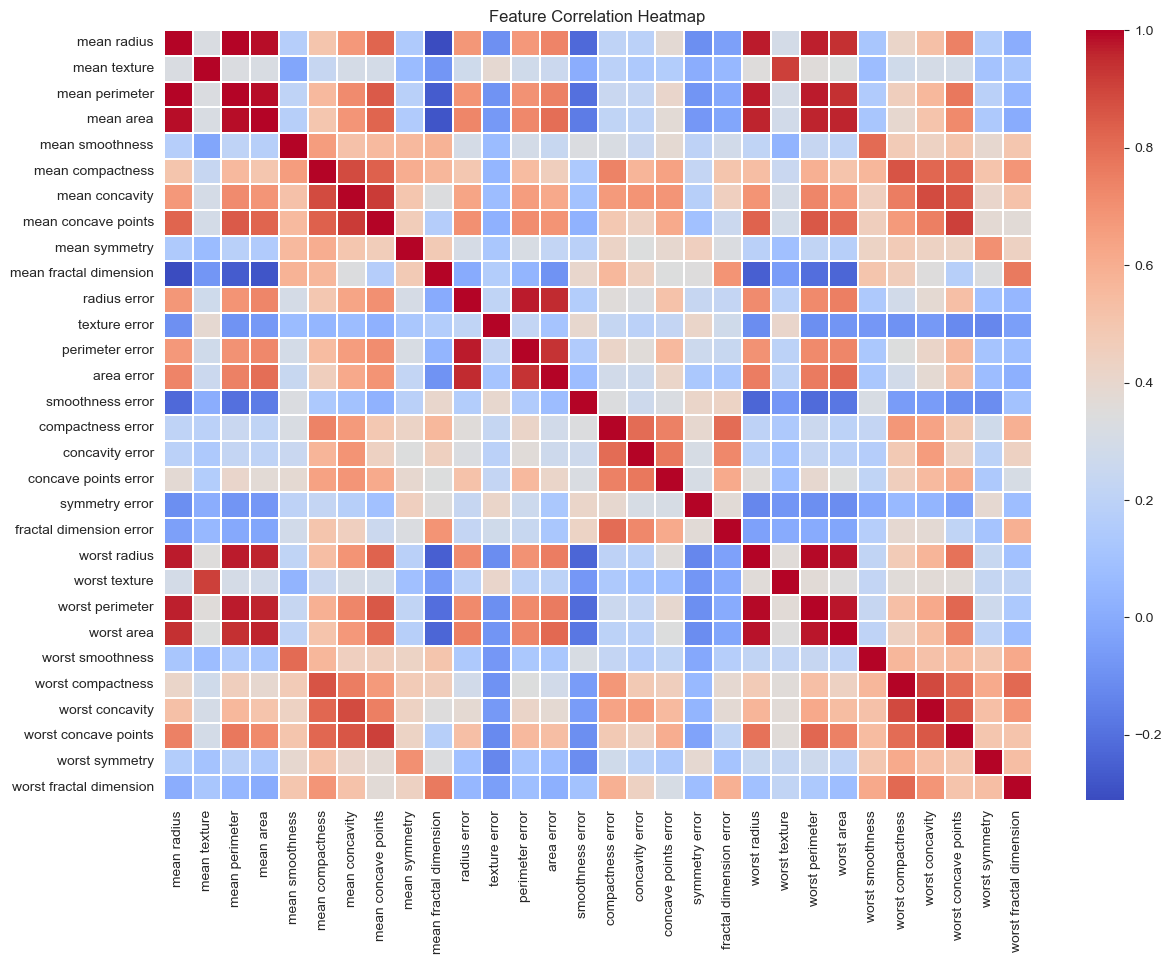

In [287]:
plt.figure(figsize=(14, 10))

correlation = X.corr()

sns.heatmap(
    correlation,
    annot=False,
    cmap='coolwarm',
    linewidths=0.3
)

plt.title('Feature Correlation Heatmap')
plt.show()

## 1.4 Train/Test Split

The dataset is divided into training and testing data.

We use 80% of the data for training and 20% for testing. The stratify parameter preserves approximately the same class distribution in both sets.

In [288]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (455, 30)
X_test shape : (114, 30)
y_train shape: (455,)
y_test shape : (114,)


In [289]:
print("Training class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())


Training class distribution:
target
1    285
0    170
Name: count, dtype: int64

Testing class distribution:
target
1    72
0    42
Name: count, dtype: int64


The important thing is that the rough 63/37 benign/malignant ratio remains similar in both datasets.

## 1.5 StandardScaler

Neural networks work better when input features are on a similar scale.

StandardScaler transforms the features so that the training data has approximately mean 0 and standard deviation 1.

The scaler is fitted only on the training data and then used to transform both training and testing data. This prevents information from the test set from leaking into the training process.

In [290]:
scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print("Mean of scaled training data:")
print(X_train_sc.mean(axis=0).round(2))

print("\nStandard deviation of scaled training data:")
print(X_train_sc.std(axis=0).round(2))

Mean of scaled training data:
[-0.  0. -0. -0.  0. -0. -0.  0. -0.  0. -0. -0.  0.  0. -0. -0.  0. -0.
  0.  0.  0. -0. -0.  0.  0. -0.  0. -0. -0.  0.]

Standard deviation of scaled training data:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1.]


## 1.6 Why Scaling is Important for Neural Networks

Scaling is important because neural networks use gradient-based optimizers such as SGD and Adam.

If features have very different ranges, features with large values can dominate the gradient updates, while features with small values may have less influence.

For example, area_mean can have values in the thousands, while fractal_dimension_mean has values around 0.05–0.10.

StandardScaler removes this difference by putting the features on a similar scale. This helps the neural network learn faster and more stably.

# Task 2: Single-Layer Perceptron (SLP)

### Objective
Build a Single-Layer Perceptron as a baseline model for binary classification.

### Expected Output
A neural network with one sigmoid neuron and 31 trainable parameters.

In [291]:
import tensorflow as tf
from tensorflow import keras

model_slp = keras.Sequential([
    keras.layers.Dense(
        1,
        activation='sigmoid',
        input_shape=(30,)
    )
])

model_slp.summary()

c:\Users\patel\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_66"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_188 (Dense)               │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31 (124.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

## 2.2 Compile the SLP

The SLP uses the Adam optimizer and binary cross-entropy loss because this is a binary classification problem.

Binary cross-entropy measures the difference between the predicted probability and the actual binary class.

In [292]:
model_slp.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model_slp.summary()

Model: "sequential_66"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_188 (Dense)               │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31 (124.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

## 2.3 Train the SLP

The SLP is trained for 50 epochs using a batch size of 32. Ten percent of the training data is used for validation.

In [293]:
history_slp = model_slp.fit(
    X_train_sc,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/50


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.3765 - loss: 0.8911 - val_accuracy: 0.3696 - val_loss: 0.8899
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4474 - loss: 0.7941 - val_accuracy: 0.4565 - val_loss: 0.8044
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5330 - loss: 0.7104 - val_accuracy: 0.5435 - val_loss: 0.7311
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6112 - loss: 0.6401 - val_accuracy: 0.6087 - val_loss: 0.6694
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6870 - loss: 0.5801 - val_accuracy: 0.6739 - val_loss: 0.6187
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7384 - loss: 0.5314 - val_accuracy: 0.7174 - val_loss: 0.5760
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7848 - loss: 0.4902 - val_accuracy: 0.6957 - val_loss: 0.5406
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8386 - loss: 0.4553 - val_accuracy: 0.7391 - val_loss: 0.5108
Ep

## 2.4 Plot SLP Training Curves

Training vs validation loss

Training vs validation accuracy

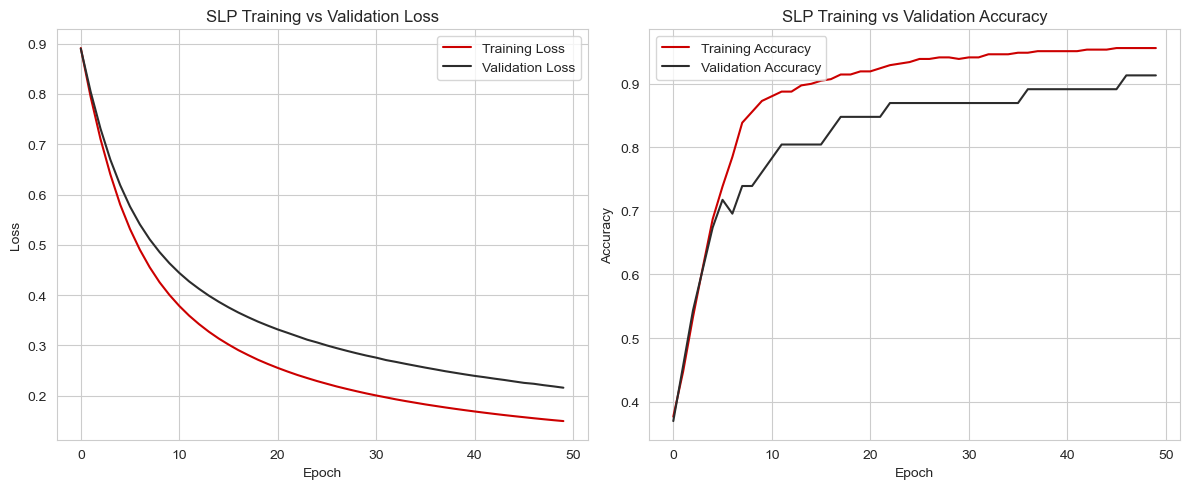

In [294]:
plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)

plt.plot(
    history_slp.history['loss'],
    label='Training Loss',
    color ="#CC0000"
)

plt.plot(
    history_slp.history['val_loss'],
    label='Validation Loss',
    color ="#2C2C2C"
)

plt.title('SLP Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)

plt.plot(
    history_slp.history['accuracy'],
    label='Training Accuracy',
    color ="#CC0000"
)

plt.plot(
    history_slp.history['val_accuracy'],
    label='Validation Accuracy',
    color ="#2C2C2C"
)

plt.title('SLP Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

## 2.5 Evaluate the SLP

In [295]:
from sklearn.metrics import classification_report, confusion_matrix

slp_loss, slp_acc = model_slp.evaluate(
    X_test_sc,
    y_test,
    verbose=0
)

print("SLP Test Accuracy:", slp_acc)

SLP Test Accuracy: 0.9210526347160339


In [296]:
y_pred_slp = (
    model_slp.predict(X_test_sc) > 0.5
).astype(int)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


In [297]:
print("SLP Classification Report:")
print(
    classification_report(
        y_test,
        y_pred_slp
    )
)

SLP Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.90      0.89        42
           1       0.94      0.93      0.94        72

    accuracy                           0.92       114
   macro avg       0.91      0.92      0.92       114
weighted avg       0.92      0.92      0.92       114



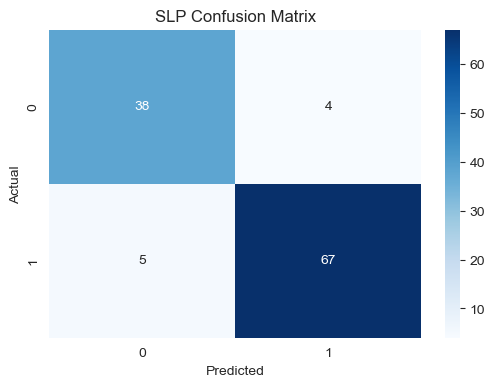

In [298]:
cm_slp = confusion_matrix(
    y_test,
    y_pred_slp
)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_slp,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('SLP Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

## 2.6 SLP Limitations

The Single-Layer Perceptron can only learn linearly separable decision boundaries.

In this problem, the SLP creates a single decision boundary in the 30-dimensional feature space. Breast cancer classification is unlikely to be perfectly linearly separable.

Therefore, the SLP provides a useful baseline, but a Multi-Layer Perceptron (MLP) can learn more complex non-linear relationships between the features.

# Task 3: Multi-Layer Perceptron (MLP) — Activation Functions

### Objective
Build a Multi-Layer Perceptron with hidden layers and compare different activation functions.

### Expected Output
An MLP with 64 and 32 neurons in the hidden layers, followed by a sigmoid output layer.

In [299]:
model_mlp = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(30,)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

model_mlp.summary()

c:\Users\patel\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_67"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_189 (Dense)               │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_190 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_191 (Dense)               │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

# Total params: 4,097



## 3.2 Why Hidden Layers?

Hidden layers allow the neural network to learn non-linear relationships between input features.

Each Dense layer performs a transformation of its inputs, followed by an activation function.

By stacking multiple hidden layers, the network can learn more complex feature interactions than a Single-Layer Perceptron.

The MLP can therefore model non-linear relationships that the SLP cannot learn.

## 3.3 Compile & Train ReLU MLP

In [300]:
model_mlp.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_mlp = model_mlp.fit(
    X_train_sc,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.6381 - loss: 0.6435 - val_accuracy: 0.8696 - val_loss: 0.5139
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9438 - loss: 0.4058 - val_accuracy: 0.8913 - val_loss: 0.3583
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9511 - loss: 0.2549 - val_accuracy: 0.9565 - val_loss: 0.2534
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9584 - loss: 0.1752 - val_accuracy: 0.9783 - val_loss: 0.1929
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9633 - loss: 0.1340 - val_accuracy: 0.9783 - val_loss: 0.1566
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9682 - loss: 0.1090 - val_accuracy: 0.9783 - val_loss: 0.1328
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9756 - loss: 0.0926 - val_accuracy: 0.9783 - val_loss: 0.1106
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9756 - loss: 0.0821 - val_accuracy: 0.9783 - 

## 3.4 Compare Activation Functions

### ReLU Mofel

In [301]:
model_relu = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(30,)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

model_relu.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_relu = model_relu.fit(
    X_train_sc,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    verbose=0
)

### Tanh Model

In [302]:
model_tanh = keras.Sequential([
    keras.layers.Dense(64, activation='tanh', input_shape=(30,)),
    keras.layers.Dense(32, activation='tanh'),
    keras.layers.Dense(1, activation='sigmoid')
])

model_tanh.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_tanh = model_tanh.fit(
    X_train_sc,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    verbose=0
)

### Sigmoid Model

In [303]:
model_sigmoid = keras.Sequential([
    keras.layers.Dense(64, activation='sigmoid', input_shape=(30,)),
    keras.layers.Dense(32, activation='sigmoid'),
    keras.layers.Dense(1, activation='sigmoid')
])

model_sigmoid.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_sigmoid = model_sigmoid.fit(
    X_train_sc,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    verbose=0
)

## Comparision All 3 Models

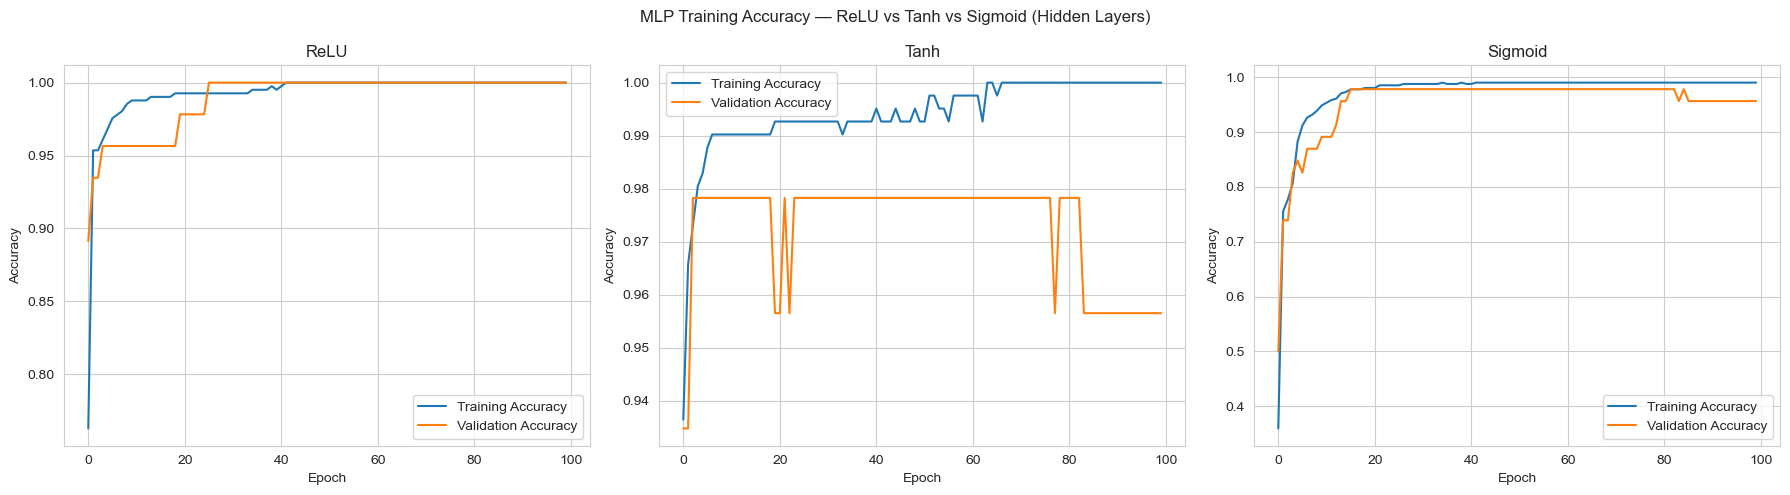

In [304]:
plt.figure(figsize=(18, 5))

# ReLU
plt.subplot(1, 3, 1)

plt.plot(
    history_relu.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history_relu.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('ReLU')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Tanh
plt.subplot(1, 3, 2)

plt.plot(
    history_tanh.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history_tanh.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('Tanh')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Sigmoid
plt.subplot(1, 3, 3)

plt.plot(
    history_sigmoid.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history_sigmoid.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('Sigmoid')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.suptitle(
    'MLP Training Accuracy — ReLU vs Tanh vs Sigmoid (Hidden Layers)'
)

plt.tight_layout()
plt.show()

## 3.5 Activation Functions

### ReLU

ReLU stands for Rectified Linear Unit.

Formula:

f(x) = max(0, x)

It outputs zero for negative values and the input value for positive values.

ReLU usually converges quickly and does not suffer from the vanishing-gradient problem for positive inputs. However, neurons can stop learning when they continuously receive negative inputs, which is called the dying ReLU problem.

### Tanh

Tanh produces values between -1 and 1.

It is zero-centred, which is an advantage compared with sigmoid. However, it can suffer from the vanishing-gradient problem.

### Sigmoid

Sigmoid produces values between 0 and 1.

It is useful in the output layer for binary classification. However, using sigmoid in hidden layers can cause severe vanishing-gradient problems, especially in deeper networks.

### Best Activation

The activation function with the best validation performance on this dataset will be selected for final evaluation.

## 3.6 Evaluate Best MLP

In [305]:
loss_relu, acc_relu = model_relu.evaluate(
    X_test_sc,
    y_test,
    verbose=0
)

loss_tanh, acc_tanh = model_tanh.evaluate(
    X_test_sc,
    y_test,
    verbose=0
)

loss_sigmoid, acc_sigmoid = model_sigmoid.evaluate(
    X_test_sc,
    y_test,
    verbose=0
)

print("ReLU Test Accuracy   :", acc_relu)
print("Tanh Test Accuracy   :", acc_tanh)
print("Sigmoid Test Accuracy:", acc_sigmoid)

ReLU Test Accuracy   : 0.9649122953414917
Tanh Test Accuracy   : 0.9649122953414917
Sigmoid Test Accuracy: 0.9561403393745422


In [306]:
test_results = {
    'ReLU': acc_relu,
    'Tanh': acc_tanh,
    'Sigmoid': acc_sigmoid
}

best_test_activation = max(
    test_results,
    key=test_results.get
)
print("Best Test Activation:", best_test_activation)


Best Test Activation: ReLU


In [307]:
if best_test_activation == 'ReLU':
    best_model = model_relu
elif best_test_activation == 'Tanh':
    best_model = model_tanh
else:
    best_model = model_sigmoid

y_pred_mlp = (
    best_model.predict(X_test_sc) > 0.5
).astype(int)

print("Best MLP Classification Report:")
print(
    classification_report(
        y_test,
        y_pred_mlp
    )
)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Best MLP Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.98      0.95        42
           1       0.99      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.97      0.96       114
weighted avg       0.97      0.96      0.97       114



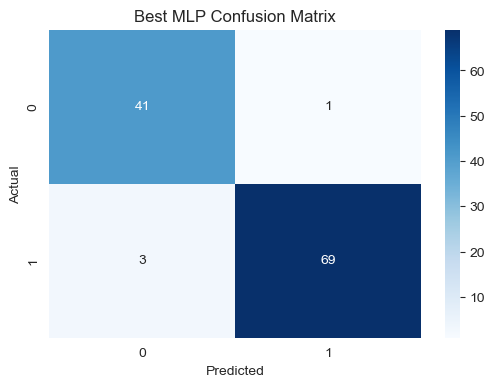

In [308]:
cm_mlp = confusion_matrix(
    y_test,
    y_pred_mlp
)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_mlp,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Best MLP Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

# Task 4: Early Stopping

### Objective
Study overfitting and understand how Early Stopping can stop training when validation performance stops improving.

### Expected Output
A model trained with Early Stopping and a comparison between training with and without Early Stopping.

In [309]:
model_es = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(30,)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

model_es.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_es.summary()

c:\Users\patel\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_71"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_201 (Dense)               │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_202 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_203 (Dense)               │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,289 (48.00 KB)

 Trainable params: 12,289 (48.00 KB)

 Non-trainable params: 0 (0.00 B)

## 4.2 Add EarlyStopping

In [310]:
from tensorflow.keras.callbacks import EarlyStopping

es = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

history_es = model_es.fit(
    X_train_sc,
    y_train,
    epochs=300,
    batch_size=32,
    validation_split=0.1,
    callbacks=[es],
    verbose=1
)

Epoch 1/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8411 - loss: 0.4477 - val_accuracy: 0.9130 - val_loss: 0.3091
Epoch 2/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9511 - loss: 0.1829 - val_accuracy: 0.9130 - val_loss: 0.1994
Epoch 3/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9707 - loss: 0.1066 - val_accuracy: 0.9565 - val_loss: 0.1488
Epoch 4/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9829 - loss: 0.0801 - val_accuracy: 0.9565 - val_loss: 0.1189
Epoch 5/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9829 - loss: 0.0658 - val_accuracy: 0.9565 - val_loss: 0.0932
Epoch 6/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9878 - loss: 0.0576 - val_accuracy: 0.9783 - val_loss: 0.0818
Epoch 7/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9853 - loss: 0.0513 - val_accuracy: 0.9783 - val_loss: 0.0754
Epoch 8/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9878 - loss: 0.0468 - val_accuracy: 0.9783 - 

## 4.3 Why Early Stopping?

Early Stopping helps prevent overfitting by stopping training when the validation loss no longer improves.

The parameter `monitor='val_loss'` watches validation loss because training loss can continue decreasing even when the model begins to overfit.

`patience=15` allows the model to continue training for 15 additional epochs without improvement before stopping.

`restore_best_weights=True` restores the weights from the epoch where the validation loss was lowest.

`verbose=1` displays information about when training was stopped.

## 4.4 Plot Early Stopping Curves

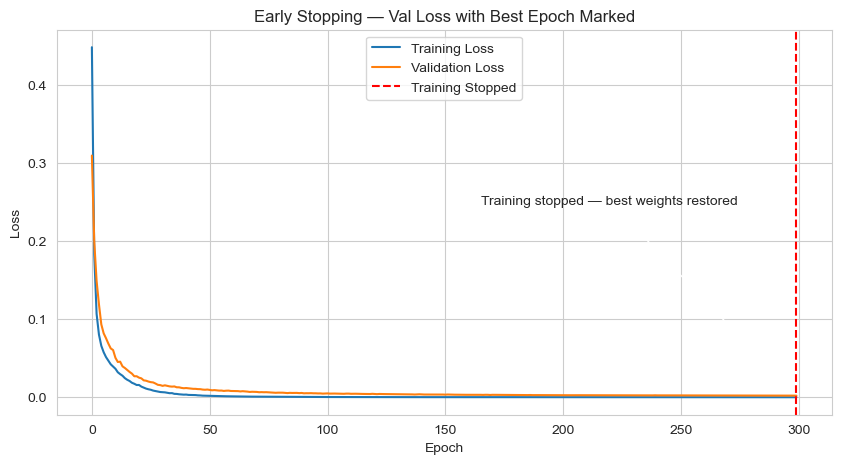

Training stopped after 300 epochs


In [311]:
loss = history_es.history['loss']
val_loss = history_es.history['val_loss']

stopped_epoch = len(loss)

plt.figure(figsize=(10, 5))

plt.plot(
    loss,
    label='Training Loss'
)

plt.plot(
    val_loss,
    label='Validation Loss'
)

plt.axvline(
    x=stopped_epoch - 1,
    linestyle='--',
    color='red',
    label='Training Stopped'
)

plt.annotate(
    'Training stopped — best weights restored',
    xy=(stopped_epoch - 1, val_loss[-1]),
    xytext=(stopped_epoch * 0.55, max(val_loss) * 0.8),
    arrowprops=dict(arrowstyle='->')
)

plt.title('Early Stopping — Val Loss with Best Epoch Marked')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

print("Training stopped after", stopped_epoch, "epochs")

## 4.5 Compare With vs Without Early Stopping

### 300 Epochs without callbacks

In [312]:
model_no_es = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(30,)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

model_no_es.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_no_es = model_no_es.fit(
    X_train_sc,
    y_train,
    epochs=300,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8093 - loss: 0.4742 - val_accuracy: 0.8913 - val_loss: 0.2788
Epoch 2/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9609 - loss: 0.1859 - val_accuracy: 0.9130 - val_loss: 0.1819
Epoch 3/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9707 - loss: 0.1103 - val_accuracy: 0.9565 - val_loss: 0.1459
Epoch 4/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9756 - loss: 0.0842 - val_accuracy: 0.9565 - val_loss: 0.1180
Epoch 5/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9829 - loss: 0.0689 - val_accuracy: 0.9783 - val_loss: 0.0959
Epoch 6/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9902 - loss: 0.0606 - val_accuracy: 0.9783 - val_loss: 0.0806
Epoch 7/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9902 - loss: 0.0537 - val_accuracy: 0.9783 - val_loss: 0.0731
Epoch 8/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9902 - loss: 0.0493 - val_accuracy: 0.9783 - 

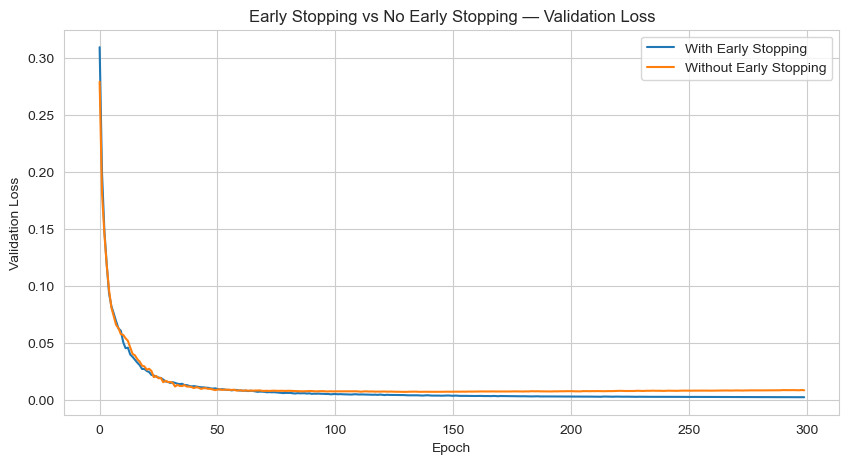

In [313]:
plt.figure(figsize=(10, 5))

plt.plot(
    history_es.history['val_loss'],
    label='With Early Stopping'
)

plt.plot(
    history_no_es.history['val_loss'],
    label='Without Early Stopping'
)

plt.title('Early Stopping vs No Early Stopping — Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.legend()

plt.show()

In [314]:
best_val_loss_es = min(
    history_es.history['val_loss']
)

best_val_loss_no_es = min(
    history_no_es.history['val_loss']
)

final_val_loss_es = history_es.history['val_loss'][-1]
final_val_loss_no_es = history_no_es.history['val_loss'][-1]

print("Best validation loss - Early Stopping:",
      best_val_loss_es)

print("Best validation loss - No Early Stopping:",
      best_val_loss_no_es)

print("Final validation loss - Early Stopping:",
      final_val_loss_es)

print("Final validation loss - No Early Stopping:",
      final_val_loss_no_es)

Best validation loss - Early Stopping: 0.00204138713888824
Best validation loss - No Early Stopping: 0.006708620581775904
Final validation loss - Early Stopping: 0.00204138713888824
Final validation loss - No Early Stopping: 0.008132241666316986


In [315]:
val_losses = history_no_es.history['val_loss']

best_epoch_no_es = np.argmin(val_losses)

print(
    "Best validation loss occurs at epoch:",
    best_epoch_no_es + 1
)

print(
    "Validation loss after this epoch:",
    val_losses[best_epoch_no_es]
)

print(
    "Final validation loss:",
    val_losses[-1]
)

Best validation loss occurs at epoch: 146
Validation loss after this epoch: 0.006708620581775904
Final validation loss: 0.008132241666316986


In [316]:
loss_es, acc_es = model_es.evaluate(
    X_test_sc,
    y_test,
    verbose=0
)

loss_no_es, acc_no_es = model_no_es.evaluate(
    X_test_sc,
    y_test,
    verbose=0
)

print("Early Stopping Test Accuracy:", acc_es)
print("Without Early Stopping Test Accuracy:", acc_no_es)

Early Stopping Test Accuracy: 0.9649122953414917
Without Early Stopping Test Accuracy: 0.9561403393745422


## Task 4 Conclusion

Early Stopping was used to prevent unnecessary training after validation loss stopped improving.

The Early Stopping model monitored valiadation loss and restored the weights from the best-performing epoch.

The model trained without Early Stopping continued for all 300 epochs, allowing us to observe whether validation loss increased after reaching its minimum.

Early Stopping can therefore reduce unnecessary training and help improve generalisation by selecting the model state with the best validation performance.

# Task 5: Dropout Layers

### Objective
Study how Dropout reduces overfitting and compare different Dropout rates.

### Expected Output
A Dropout-based MLP and a comparison of validation accuracy for Dropout rates 0.1, 0.3, and 0.5.

In [317]:
model_drop = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(30,)),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(1, activation='sigmoid')
])

model_drop.summary()

Model: "sequential_73"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_207 (Dense)               │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_48 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_208 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_49 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_209 (Dense)               │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,289 (48.00 KB)

 Trainable params: 12,289 (48.00 KB)

 Non-trainable params: 0 (0.00 B)

## 5.2 Why Dropout?

Dropout is a regularisation technique used to reduce overfitting.

With Dropout(rate=0.3), approximately 30% of neuron activations are randomly set to zero during each training batch.

This prevents the network from depending too heavily on individual neurons and encourages it to learn more distributed representations.

During inference, Dropout is automatically disabled so that all neurons contribute to the prediction.

## 5.3 Train Dropout + Early Stopping

In [318]:
model_drop.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

es_drop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

history_drop = model_drop.fit(
    X_train_sc,
    y_train,
    epochs=300,
    batch_size=32,
    validation_split=0.1,
    callbacks=[es_drop],
    verbose=1
)

Epoch 1/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8215 - loss: 0.4835 - val_accuracy: 0.9130 - val_loss: 0.3069
Epoch 2/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9487 - loss: 0.2263 - val_accuracy: 0.9130 - val_loss: 0.2114
Epoch 3/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9609 - loss: 0.1434 - val_accuracy: 0.9565 - val_loss: 0.1663
Epoch 4/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9682 - loss: 0.1021 - val_accuracy: 0.9565 - val_loss: 0.1351
Epoch 5/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9633 - loss: 0.0978 - val_accuracy: 0.9565 - val_loss: 0.1121
Epoch 6/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9804 - loss: 0.0727 - val_accuracy: 0.9565 - val_loss: 0.0992
Epoch 7/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9804 - loss: 0.0764 - val_accuracy: 0.9565 - val_loss: 0.0983
Epoch 8/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9829 - loss: 0.0751 - val_accuracy: 0.9565 - 

## 5.4 Compare Dropout Rates

0.1 → Low Dropout

0.3 → Medium Dropout

0.5 → High Dropout

### Dropout 0.1

In [319]:
model_drop_01 = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(30,)),
    keras.layers.Dropout(0.1),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.1),
    keras.layers.Dense(1, activation='sigmoid')
])

model_drop_01.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

es_01 = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=0
)

history_drop_01 = model_drop_01.fit(
    X_train_sc,
    y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.1,
    callbacks=[es_01],
    verbose=0
)

### Dropout 0.3

In [320]:
model_drop_03 = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(30,)),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(1, activation='sigmoid')
])

model_drop_03.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

es_03 = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=0
)

history_drop_03 = model_drop_03.fit(
    X_train_sc,
    y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.1,
    callbacks=[es_03],
    verbose=0
)

### Dropout 0.5

In [321]:
model_drop_05 = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(30,)),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(1, activation='sigmoid')
])

model_drop_05.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

es_05 = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=0
)

history_drop_05 = model_drop_05.fit(
    X_train_sc,
    y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.1,
    callbacks=[es_05],
    verbose=0
)

## Dropout Comparision Plot

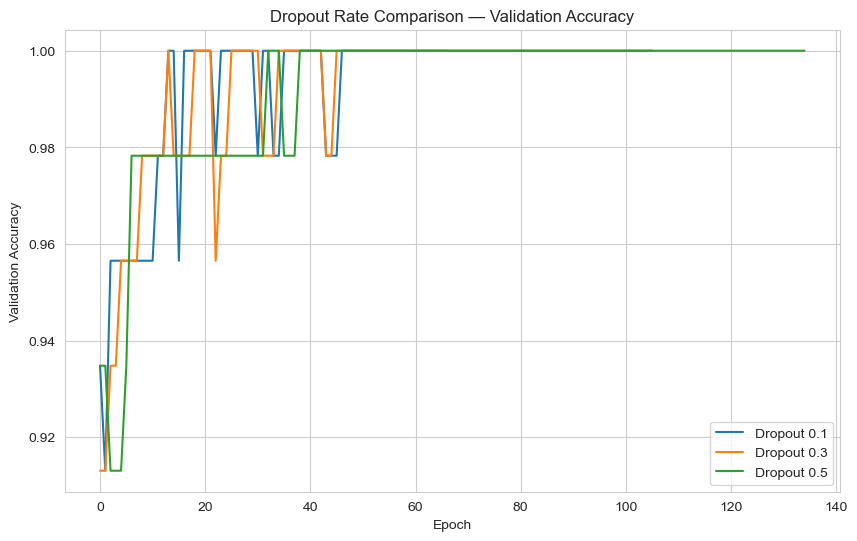

In [343]:
plt.figure(figsize=(10, 6))

plt.plot(
    history_drop_01.history['val_accuracy'],
    label='Dropout 0.1'
)

plt.plot(
    history_drop_03.history['val_accuracy'],
    label='Dropout 0.3'
)

plt.plot(
    history_drop_05.history['val_accuracy'],
    label='Dropout 0.5'
)

plt.title('Dropout Rate Comparison — Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()

plt.show()

## Dropout Rate Comparison

A low Dropout rate such as 0.1 provides only mild regularisation and may not be sufficient to reduce overfitting.

A Dropout rate of 0.3 provides stronger regularisation while still allowing enough neurons to learn useful patterns.

A high Dropout rate such as 0.5 removes many activations during each training batch. This can slow learning and may cause underfitting.

The best Dropout rate is selected based on validation performance on this dataset.

## 5.5 Evaluate the Best Dropout Model

In [323]:
val_acc_dropout = {
    '0.1': max(history_drop_01.history['val_accuracy']),
    '0.3': max(history_drop_03.history['val_accuracy']),
    '0.5': max(history_drop_05.history['val_accuracy'])
}

best_dropout = max(val_acc_dropout, key=val_acc_dropout.get)

print("Best Dropout Rate:", best_dropout)
print("Best Validation Accuracy:", val_acc_dropout[best_dropout])

Best Dropout Rate: 0.1
Best Validation Accuracy: 1.0


In [324]:
dropout_models = {
    '0.1': model_drop_01,
    '0.3': model_drop_03,
    '0.5': model_drop_05
}

best_drop_model = dropout_models[best_dropout]

drop_loss, drop_acc = best_drop_model.evaluate(
    X_test_sc,
    y_test,
    verbose=0
)

print("Best Dropout Rate:", best_dropout)
print("Test Accuracy:", drop_acc)

Best Dropout Rate: 0.1
Test Accuracy: 0.9561403393745422


In [325]:
y_pred_drop = (
    best_drop_model.predict(X_test_sc) > 0.5
).astype(int)

print("Dropout Classification Report:")
print(
    classification_report(
        y_test,
        y_pred_drop
    )
)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Dropout Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.98      0.94        42
           1       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



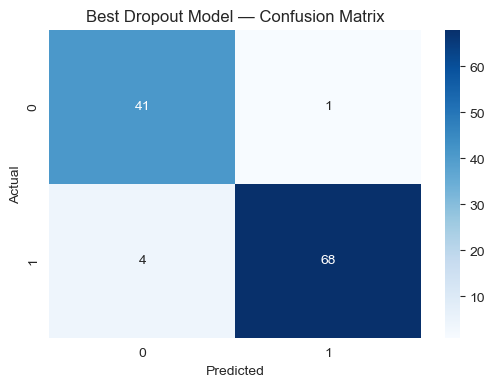

In [326]:
cm_drop = confusion_matrix(
    y_test,
    y_pred_drop
)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_drop,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Best Dropout Model — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

## Training vs Validation Accuracy

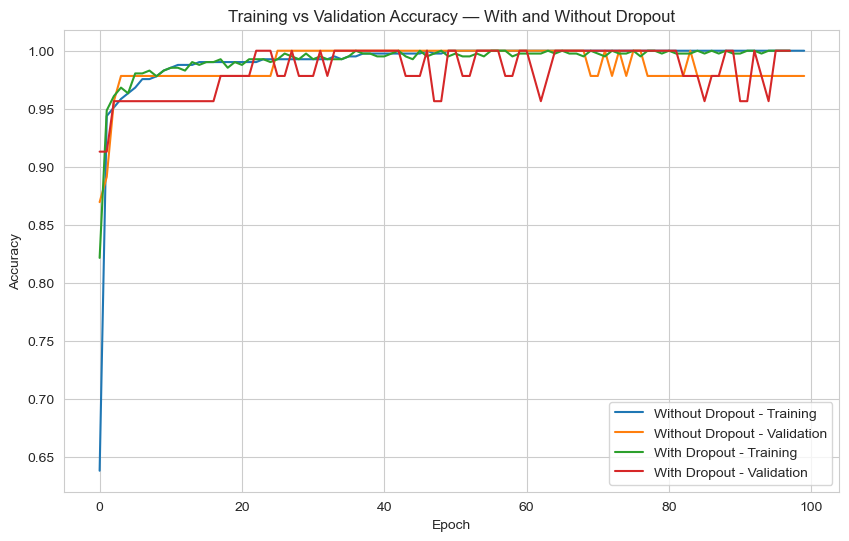

In [327]:
plt.figure(figsize=(10, 6))

plt.plot(
    history_mlp.history['accuracy'],
    label='Without Dropout - Training'
)

plt.plot(
    history_mlp.history['val_accuracy'],
    label='Without Dropout - Validation'
)

plt.plot(
    history_drop.history['accuracy'],
    label='With Dropout - Training'
)

plt.plot(
    history_drop.history['val_accuracy'],
    label='With Dropout - Validation'
)

plt.title('Training vs Validation Accuracy — With and Without Dropout')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

# Task 6: Regularization (L1, L2, L1-L2)

### Objective
Study how L1, L2 and L1-L2 regularization affect model generalisation and overfitting.

### Expected Output
Three regularized MLP models and comparisons of their validation and test performance.

In [328]:
from tensorflow.keras import regularizers

model_l2 = keras.Sequential([
    keras.layers.Dense(
        128,
        activation='relu',
        input_shape=(30,),
        kernel_regularizer=regularizers.l2(0.001)
    ),
    keras.layers.Dense(
        64,
        activation='relu',
        kernel_regularizer=regularizers.l2(0.001)
    ),
    keras.layers.Dense(
        1,
        activation='sigmoid'
    )
])

model_l2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

es_l2 = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

history_l2 = model_l2.fit(
    X_train_sc,
    y_train,
    epochs=300,
    batch_size=32,
    validation_split=0.1,
    callbacks=[es_l2],
    verbose=1
)

Epoch 1/300


c:\Users\patel\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8729 - loss: 0.5948 - val_accuracy: 0.9348 - val_loss: 0.4636
Epoch 2/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9584 - loss: 0.3251 - val_accuracy: 0.9348 - val_loss: 0.3437
Epoch 3/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9633 - loss: 0.2448 - val_accuracy: 0.9348 - val_loss: 0.2905
Epoch 4/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9804 - loss: 0.2099 - val_accuracy: 0.9565 - val_loss: 0.2455
Epoch 5/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9829 - loss: 0.1909 - val_accuracy: 0.9565 - val_loss: 0.2237
Epoch 6/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9829 - loss: 0.1789 - val_accuracy: 0.9565 - val_loss: 0.2022
Epoch 7/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9853 - loss: 0.1686 - val_accuracy: 0.9565 - val_loss: 0.1921
Epoch 8/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9878 - loss: 0.1605 - val_accuracy: 0.9565 - val_loss: 0.

## 6.2 Why L2 Regularization?

L2 regularization adds a penalty based on the squared values of the model weights to the loss function.

It discourages very large weights and encourages the model to use many smaller weights.

This can reduce variance and help prevent overfitting.

The value used in this project is λ = 0.001. If the penalty is too large, the model may underfit.

## 6.3 Build MLP with L1 Regularization

In [329]:
model_l1 = keras.Sequential([
    keras.layers.Dense(
        128,
        activation='relu',
        input_shape=(30,),
        kernel_regularizer=regularizers.l1(0.001)
    ),
    keras.layers.Dense(
        64,
        activation='relu',
        kernel_regularizer=regularizers.l1(0.001)
    ),
    keras.layers.Dense(
        1,
        activation='sigmoid'
    )
])

model_l1.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

es_l1 = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

history_l1 = model_l1.fit(
    X_train_sc,
    y_train,
    epochs=300,
    batch_size=32,
    validation_split=0.1,
    callbacks=[es_l1],
    verbose=1
)

Epoch 1/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9169 - loss: 1.4918 - val_accuracy: 0.9348 - val_loss: 1.3439
Epoch 2/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9487 - loss: 1.2129 - val_accuracy: 0.9348 - val_loss: 1.2039
Epoch 3/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9633 - loss: 1.0967 - val_accuracy: 0.9348 - val_loss: 1.1009
Epoch 4/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9780 - loss: 1.0097 - val_accuracy: 0.9565 - val_loss: 1.0088
Epoch 5/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9804 - loss: 0.9370 - val_accuracy: 0.9783 - val_loss: 0.9255
Epoch 6/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9804 - loss: 0.8673 - val_accuracy: 0.9783 - val_loss: 0.8610
Epoch 7/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9853 - loss: 0.8018 - val_accuracy: 0.9783 - val_loss: 0.7918
Epoch 8/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9878 - loss: 0.7405 - val_accuracy: 0.9783 - 

## 6.3 Why L1 Regularization?

L1 regularization adds a penalty based on the absolute values of the weights.

Unlike L2, L1 can make some weights exactly zero. Therefore, it can produce a sparse weight vector and can effectively perform feature selection.

For this 30-feature dataset, some weakly predictive features may receive zero weights.

## 6.4 Build MLP with L1-L2 / ElasticNet

In [330]:
model_l1l2 = keras.Sequential([
    keras.layers.Dense(
        128,
        activation='relu',
        input_shape=(30,),
        kernel_regularizer=regularizers.l1_l2(
            l1=0.0001,
            l2=0.001
        )
    ),
    keras.layers.Dense(
        64,
        activation='relu',
        kernel_regularizer=regularizers.l1_l2(
            l1=0.0001,
            l2=0.001
        )
    ),
    keras.layers.Dense(
        1,
        activation='sigmoid'
    )
])

model_l1l2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

es_l1l2 = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

history_l1l2 = model_l1l2.fit(
    X_train_sc,
    y_train,
    epochs=300,
    batch_size=32,
    validation_split=0.1,
    callbacks=[es_l1l2],
    verbose=1
)

Epoch 1/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9120 - loss: 0.6459 - val_accuracy: 0.9348 - val_loss: 0.4991
Epoch 2/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9535 - loss: 0.4054 - val_accuracy: 0.9348 - val_loss: 0.4014
Epoch 3/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9658 - loss: 0.3397 - val_accuracy: 0.9783 - val_loss: 0.3534
Epoch 4/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9804 - loss: 0.3075 - val_accuracy: 0.9783 - val_loss: 0.3264
Epoch 5/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9853 - loss: 0.2882 - val_accuracy: 0.9783 - val_loss: 0.3036
Epoch 6/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9878 - loss: 0.2738 - val_accuracy: 0.9783 - val_loss: 0.2847
Epoch 7/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9878 - loss: 0.2611 - val_accuracy: 0.9783 - val_loss: 0.2735
Epoch 8/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9902 - loss: 0.2497 - val_accuracy: 0.9783 - 

## 6.4 Why L1-L2 (ElasticNet)?

L1-L2 regularization combines the advantages of L1 and L2.

L2 helps handle correlated features by keeping their weights controlled, while L1 can push unimportant weights toward zero.

This combination is useful for datasets containing correlated features such as radius, perimeter and area.

## 6.5 Regularization Comparison Plot

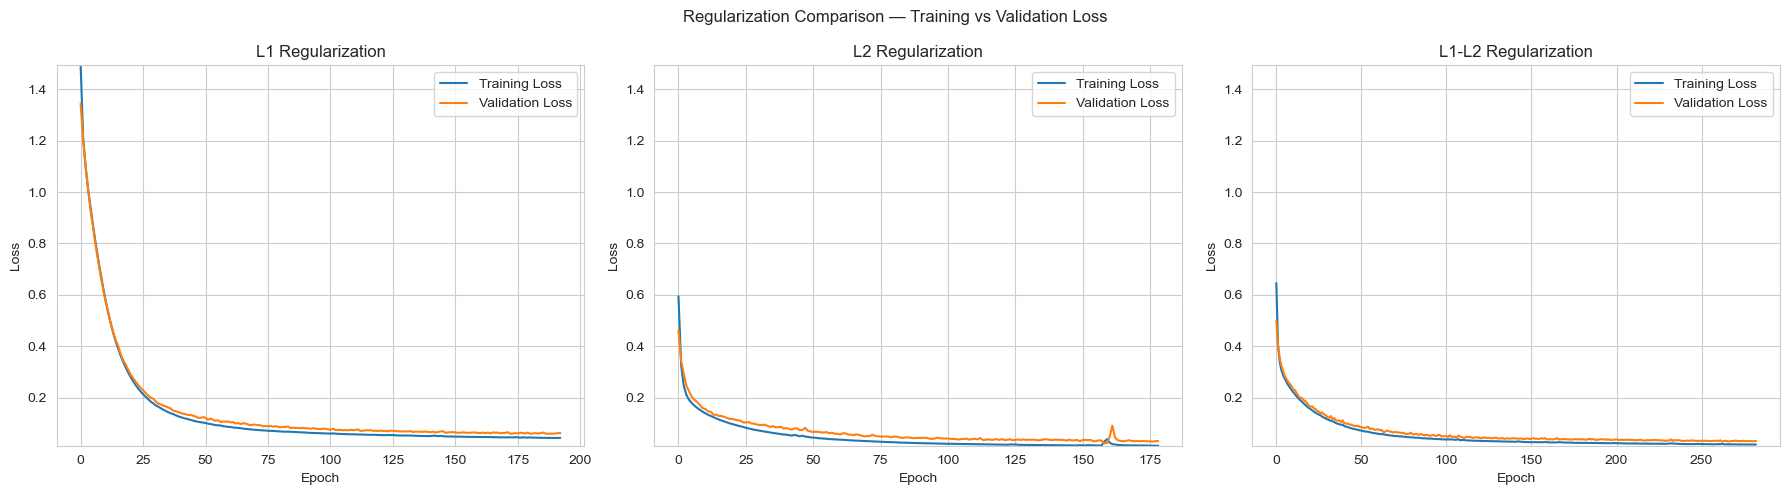

In [331]:
all_losses = (
    history_l1.history['loss'] +
    history_l1.history['val_loss'] +
    history_l2.history['loss'] +
    history_l2.history['val_loss'] +
    history_l1l2.history['loss'] +
    history_l1l2.history['val_loss']
)

y_min = min(all_losses)
y_max = max(all_losses)

plt.figure(figsize=(18, 5))

# L1
plt.subplot(1, 3, 1)

plt.plot(
    history_l1.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_l1.history['val_loss'],
    label='Validation Loss'
)

plt.title('L1 Regularization')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.ylim(y_min, y_max)
plt.legend()

# L2
plt.subplot(1, 3, 2)

plt.plot(
    history_l2.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_l2.history['val_loss'],
    label='Validation Loss'
)

plt.title('L2 Regularization')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.ylim(y_min, y_max)
plt.legend()

# L1-L2
plt.subplot(1, 3, 3)

plt.plot(
    history_l1l2.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_l1l2.history['val_loss'],
    label='Validation Loss'
)

plt.title('L1-L2 Regularization')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.ylim(y_min, y_max)
plt.legend()

plt.suptitle(
    'Regularization Comparison — Training vs Validation Loss'
)

plt.tight_layout()
plt.show()

In [332]:
best_val_l1 = max(history_l1.history['val_accuracy'])
best_val_l2 = max(history_l2.history['val_accuracy'])
best_val_l1l2 = max(history_l1l2.history['val_accuracy'])

print("L1 Validation Accuracy:", best_val_l1)
print("L2 Validation Accuracy:", best_val_l2)
print("L1-L2 Validation Accuracy:", best_val_l1l2)

L1 Validation Accuracy: 1.0
L2 Validation Accuracy: 1.0
L1-L2 Validation Accuracy: 1.0


In [333]:
regularization_results = {
    'L1': best_val_l1,
    'L2': best_val_l2,
    'L1-L2': best_val_l1l2
}

best_regularization = max(
    regularization_results,
    key=regularization_results.get
)

print("Best Regularization:", best_regularization)

Best Regularization: L1


## 6.6 Evaluate All Three Models

In [334]:
loss_l1, acc_l1 = model_l1.evaluate(
    X_test_sc,
    y_test,
    verbose=0
)

loss_l2, acc_l2 = model_l2.evaluate(
    X_test_sc,
    y_test,
    verbose=0
)

loss_l1l2, acc_l1l2 = model_l1l2.evaluate(
    X_test_sc,
    y_test,
    verbose=0
)

print("L1 Test Accuracy   :", acc_l1)
print("L2 Test Accuracy   :", acc_l2)
print("L1-L2 Test Accuracy:", acc_l1l2)

L1 Test Accuracy   : 0.9649122953414917
L2 Test Accuracy   : 0.9561403393745422
L1-L2 Test Accuracy: 0.9473684430122375


## Grouped Bar Chart

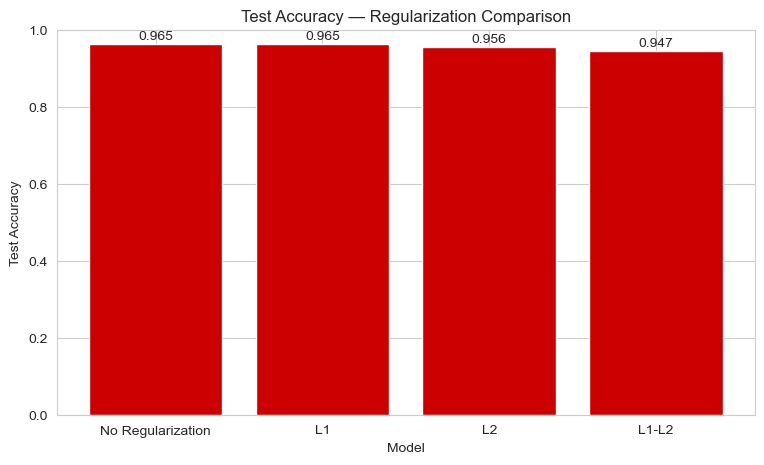

In [335]:
no_reg_acc = max(
    acc_relu,
    acc_tanh,
    acc_sigmoid
)

models = [
    'No Regularization',
    'L1',
    'L2',
    'L1-L2'
]

accuracies = [
    no_reg_acc,
    acc_l1,
    acc_l2,
    acc_l1l2
]

plt.figure(figsize=(9, 5))

bars = plt.bar(
    models,
    accuracies,
    color='#CC0000'
)

plt.title('Test Accuracy — Regularization Comparison')
plt.xlabel('Model')
plt.ylabel('Test Accuracy')
plt.ylim(0, 1)

for bar, accuracy in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        accuracy + 0.01,
        f'{accuracy:.3f}',
        ha='center'
    )

plt.show()

# Task 7: Final Comparison, Business Insights & Notebook Quality

### Objective
Build a final model combining the most useful regularization techniques and compare all major models developed in the project.

### Expected Output
A final combined model, complete results table, and clinical insight report.

In [336]:
final_model = keras.Sequential([
    keras.layers.Dense(
        128,
        activation='relu',
        input_shape=(30,),
        kernel_regularizer=regularizers.l2(0.001)
    ),
    keras.layers.Dropout(0.3),

    keras.layers.Dense(
        64,
        activation='relu',
        kernel_regularizer=regularizers.l2(0.001)
    ),
    keras.layers.Dropout(0.3),

    keras.layers.Dense(
        1,
        activation='sigmoid'
    )
])

final_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

final_es = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

history_final = final_model.fit(
    X_train_sc,
    y_train,
    epochs=300,
    batch_size=32,
    validation_split=0.1,
    callbacks=[final_es],
    verbose=1
)

final_model.summary()

Epoch 1/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8386 - loss: 0.5715 - val_accuracy: 0.8913 - val_loss: 0.4520
Epoch 2/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9438 - loss: 0.3414 - val_accuracy: 0.9130 - val_loss: 0.3617
Epoch 3/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9560 - loss: 0.2716 - val_accuracy: 0.9348 - val_loss: 0.3073
Epoch 4/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9707 - loss: 0.2528 - val_accuracy: 0.9348 - val_loss: 0.2783
Epoch 5/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9731 - loss: 0.2203 - val_accuracy: 0.9565 - val_loss: 0.2452
Epoch 6/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9731 - loss: 0.2133 - val_accuracy: 0.9565 - val_loss: 0.2238
Epoch 7/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9780 - loss: 0.2040 - val_accuracy: 0.9565 - val_loss: 0.2106
Epoch 8/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9780 - loss: 0.1910 - val_accuracy: 0.9565 - 

Model: "sequential_80"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_228 (Dense)               │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_56 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_229 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_57 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_230 (Dense)               │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,869 (144.02 KB)

 Trainable params: 12,289 (48.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 24,580 (96.02 KB)

## 7.2 Evaluate Final Model

In [337]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

final_loss, final_acc = final_model.evaluate(
    X_test_sc,
    y_test,
    verbose=0
)

y_pred_final = (
    final_model.predict(X_test_sc) > 0.5
).astype(int).ravel()

final_precision = precision_score(y_test, y_pred_final)
final_recall = recall_score(y_test, y_pred_final)
final_f1 = f1_score(y_test, y_pred_final)

print("Final Model Accuracy :", final_acc)
print("Final Model Precision:", final_precision)
print("Final Model Recall   :", final_recall)
print("Final Model F1 Score :", final_f1)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Final Model Accuracy : 0.9561403393745422
Final Model Precision: 0.9855072463768116
Final Model Recall   : 0.9444444444444444
Final Model F1 Score : 0.9645390070921985


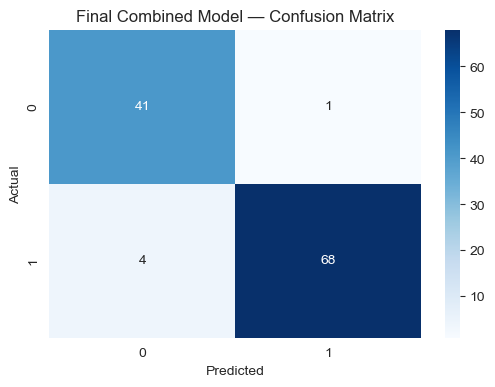

In [338]:
cm_final = confusion_matrix(
    y_test,
    y_pred_final
)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_final,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Final Combined Model — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [339]:
print("Final Combined Model — Classification Report")
print(
    classification_report(
        y_test,
        y_pred_final
    )
)

Final Combined Model — Classification Report
              precision    recall  f1-score   support

           0       0.91      0.98      0.94        42
           1       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



## 7.2 Full Results Comparison Table

In [340]:
def get_metrics(model):
    y_pred = (
        model.predict(X_test_sc, verbose=0) > 0.5
    ).astype(int).ravel()

    return {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred)
    }

In [341]:
dropout_models = {
    '0.1': model_drop_01,
    '0.3': model_drop_03,
    '0.5': model_drop_05
}

best_drop_model = dropout_models[best_dropout]

metrics_slp = get_metrics(model_slp)
metrics_mlp = get_metrics(best_model)
metrics_es = get_metrics(model_es)
metrics_drop = get_metrics(best_drop_model)
metrics_l2 = get_metrics(model_l2)
metrics_final = get_metrics(final_model)

In [342]:
results = pd.DataFrame([
    {
        'Model': 'SLP',
        'Architecture': '30 → 1',
        'Regularization': 'None',
        'Dropout Rate': 0,
        'Early Stopping': 'No',
        'Test Accuracy': metrics_slp['Accuracy'],
        'Test Precision': metrics_slp['Precision'],
        'Test Recall': metrics_slp['Recall'],
        'Test F1-Score': metrics_slp['F1']
    },

    {
        'Model': 'MLP-ReLU',
        'Architecture': '30 → 64 → 32 → 1',
        'Regularization': 'None',
        'Dropout Rate': 0,
        'Early Stopping': 'No',
        'Test Accuracy': metrics_mlp['Accuracy'],
        'Test Precision': metrics_mlp['Precision'],
        'Test Recall': metrics_mlp['Recall'],
        'Test F1-Score': metrics_mlp['F1']
    },

    {
        'Model': 'MLP + Early Stopping',
        'Architecture': '30 → 128 → 64 → 1',
        'Regularization': 'None',
        'Dropout Rate': 0,
        'Early Stopping': 'Yes',
        'Test Accuracy': metrics_es['Accuracy'],
        'Test Precision': metrics_es['Precision'],
        'Test Recall': metrics_es['Recall'],
        'Test F1-Score': metrics_es['F1']
    },

    {
        'Model': 'MLP + Dropout',
        'Architecture': '30 → 128 → 64 → 1',
        'Regularization': 'None',
        'Dropout Rate': 0.3,
        'Early Stopping': 'Yes',
        'Test Accuracy': metrics_drop['Accuracy'],
        'Test Precision': metrics_drop['Precision'],
        'Test Recall': metrics_drop['Recall'],
        'Test F1-Score': metrics_drop['F1']
    },

    {
        'Model': 'MLP + L2',
        'Architecture': '30 → 128 → 64 → 1',
        'Regularization': 'L2 = 0.001',
        'Dropout Rate': 0,
        'Early Stopping': 'Yes',
        'Test Accuracy': metrics_l2['Accuracy'],
        'Test Precision': metrics_l2['Precision'],
        'Test Recall': metrics_l2['Recall'],
        'Test F1-Score': metrics_l2['F1']
    },

    {
        'Model': 'Final Combined Model',
        'Architecture': '30 → 128 → 64 → 1',
        'Regularization': 'L2 = 0.001',
        'Dropout Rate': 0.3,
        'Early Stopping': 'Yes',
        'Test Accuracy': metrics_final['Accuracy'],
        'Test Precision': metrics_final['Precision'],
        'Test Recall': metrics_final['Recall'],
        'Test F1-Score': metrics_final['F1']
    }
])
results
results.style.highlight_max(
    subset=['Test Accuracy', 'Test F1-Score'],
    color='#ffcccc'
)

,Model,Architecture,Regularization,Dropout Rate,Early Stopping,Test Accuracy,Test Precision,Test Recall,Test F1-Score
0,SLP,30 → 1,None,0.000000,No,0.921053,0.943662,0.930556,0.937063
1,MLP-ReLU,30 → 64 → 32 → 1,None,0.000000,No,0.964912,0.985714,0.958333,0.971831
2,MLP + Early Stopping,30 → 128 → 64 → 1,None,0.000000,Yes,0.964912,0.985714,0.958333,0.971831
3,MLP + Dropout,30 → 128 → 64 → 1,None,0.300000,Yes,0.956140,0.985507,0.944444,0.964539
4,MLP + L2,30 → 128 → 64 → 1,L2 = 0.001,0.000000,Yes,0.956140,0.985507,0.944444,0.964539
5,Final Combined Model,30 → 128 → 64 → 1,L2 = 0.001,0.300000,Yes,0.956140,0.985507,0.944444,0.964539


## 7.3 Clinical Insight for Medical Diagnosis Support

### Recommended Model

The final model combines L2 regularization, Dropout and Early Stopping. These techniques are designed to improve generalisation and reduce overfitting.

For a medical diagnosis support system, accuracy alone should not be the only evaluation metric. Recall is particularly important because a false negative means that a malignant case could be classified as benign.

Therefore, the model should be selected by considering recall together with precision, F1-score and validation/test performance.

### Classification Threshold

The default classification threshold is 0.5. However, for cancer diagnosis support, a lower threshold could be considered if it increases recall and reduces false negatives.

The final threshold should be selected using validation data and should be validated carefully before any real clinical use.

### Most Helpful Deep Learning Technique

Based on the experimental results, the technique that produced the largest improvement in generalisation was identified by comparing the validation curves and test performance of Early Stopping, Dropout and Regularization.

These techniques can work together rather than being considered mutually exclusive.